# Агрегирование данных по ячейкам регулярной сетки


В предыдущем разделе мы выполняли анализ данных в пределах административных границ. Однако такие границы не всегда подходят для задач пространственного анализа, так как они могут существенно различаться по размеру и форме.

В качестве альтернативы часто используется регулярная сетка — разбиение территории на одинаковые ячейки. Это позволяет более равномерно анализировать пространственные данные и выявлять закономерности их размещения.

В этом разделе мы посчитаем плотность размещения кафе в Центральном районе Санкт-Петербурга. Для этого:

- Построим регулярную сетку квадратных ячеек, покрывающую интересующую нас территорию.
- Выполним пространственное объединение: определим, сколько кафе попадает в каждую ячейку.
- Вычислим плотность кафе (количество на км²) по ячейкам и визуализируем результат.


## 0. Импортируем библиотеки и подготавливаем данные


### 0.1 Импорт библиотек


In [39]:
import pandas as pd  
import geopandas as gpd
import osmnx as ox

- [**pandas**](https://pandas.pydata.org/) (`pandas`) — библиотека Python для работы с табличными данными.

- [**GeoPandas**](https://geopandas.org/) (`geopandas`) — библиотека Python, расширение библиотеки pandas, предназначенное для работы с геопространственными данными. Позволяет загружать, обрабатывать и анализировать пространственные наборы данных в различных форматах.

- [**OSMnx**](https://osmnx.readthedocs.io/) (`osmnx`) — библиотека Python для загрузки, анализа и визуализации данных **OpenStreetMap**.
  Она позволяет легко получать пространственные объекты по названию места или по координатам.


### 0.2 Подготовка данных


Загрузим границу Центрального района Санкт-Петербурга из OpenStreetMap


In [40]:
area_name = "Центральный район, Санкт-Петербург"
admin_border = ox.geocode_to_gdf(area_name)

admin_border.explore(tiles="cartodbpositron")

Также загрузим информацию о кафе из OpenStreetMap и отберём только нужные атрибуты


In [41]:
tags = {
    "amenity": "cafe"
}

cafes = ox.features_from_place(
    area_name,
    tags
)

В наборе данных с кафе оставим только несколько самых важных атрибутов


In [42]:
cafes["osm_id"] = cafes.index.get_level_values("id")
cafes = cafes[["osm_id", "cuisine", "name", "geometry"]]
cafes.head()

osm_id      cuisine        name  \
element id                                              
node    444776758  444776758      chinese      Wahaha   
        446064734  446064734          NaN         NaN   
        446064736  446064736  coffee_shop  Flat White   
        455299275  455299275          NaN     Хлебник   
        652383850  652383850          NaN     Feromon   

                                    geometry  
element id                                    
node    444776758  POINT (30.36421 59.93049)  
        446064734  POINT (30.34693 59.91807)  
        446064736   POINT (30.3464 59.91839)  
        455299275   POINT (30.3601 59.93743)  
        652383850  POINT (30.32636 59.93642)

Посмотрим на объекты на карте


In [43]:
cafes.explore(tiles="cartodbpositron")

При отображении точечных объектов на карте сложно количественно оценить их распределение, особенно в местах с высокой плотностью, где точки могут перекрываться.

Для более наглядного анализа в этом разделе мы построим регулярную сетку и выполним агрегирование данных, подсчитав количество кафе в каждой ячейке.


## 1. Создание сетки регулярных ячеек


Перед созданием регулярной сетки необходимо определить, **в каких границах она будет построена**, а также задать **размер и форму ячеек**.

Границы сетки обычно задаются по области исследования (в нашем случае — по границе района), а размер ячеек — чаще всего в метрах.

Ячейки могут иметь различную форму (например, квадратную или гексагональную), однако в рамках данного раздела мы будем использовать **квадратную сетку** как наиболее простую и распространённую.

В связи с этим важно обратить внимание на систему координат исходных данных. Для корректного построения ячеек и задания их размера необходимо использовать **проекционную систему координат**, а не географическую.


### 1.1. Перепроецирование исходных данных


Проверим систему координат у наборов данных с границами района и кафе. При необходимости выполним перепроецирование в подходящую UTM-зону.


In [44]:
print("СК admin_border:", admin_border.crs)
print("СК cafes:", cafes.crs)

СК admin_border: epsg:4326
СК cafes: epsg:4326


Система координат EPSG:4326 — это географическая система координат WGS-84. В ней координаты заданы в градусах, поэтому она не подходит для задач, связанных с измерением расстояний и площадей.
В данном случае нам необходимо работать с размерами ячеек в метрах, поэтому перепроецируем данные в подходящую проекционную систему координат.


Определим подходящую UTM-зону для наших данных. Поскольку все используемые наборы данных относятся к одной и той же территории, достаточно выполнить эту операцию только для одного из них.


In [45]:
utm_data = admin_border.estimate_utm_crs()

Перепроецируем данные:


In [46]:
admin_border_utm = admin_border.to_crs(utm_data)
cafes_utm = cafes.to_crs(utm_data)

### 1.2. Определение границ территории

Теперь необходимо определить, в пределах какой территории будет построена сетка. Для этого найдём экстент (охват) области исследования.

Экстент задаётся минимальными и максимальными значениями координат по осям X и Y, которые определяют ограничивающий прямоугольник для построения сетки.

В GeoPandas для этого используется атрибут `total_bounds`, который возвращает четыре значения: `minx`, `miny`, `maxx`, `maxy`.


In [47]:
minx, miny, maxx, maxy = admin_border_utm.total_bounds

print(minx, miny, maxx, maxy)

349622.32554533915 6644753.92436025 354962.8870234521 6649601.4031880805


Полученные значения задают границы области, в пределах которой будет построена сетка.


### 1.3. Определение размера ячейки

Размер ячейки — один из ключевых параметров при построении регулярной сетки, так как он напрямую влияет на результаты анализа.

Слишком крупные ячейки приводят к сильному обобщению данных: локальные различия сглаживаются, и детальная структура распределения объектов может быть потеряна. Слишком мелкие ячейки, напротив, делают результат более детализированным, но могут приводить к «шуму» и большому числу пустых ячеек.

Оптимальный размер зависит от конкретной задачи и плотности данных, поэтому на практике часто имеет смысл **экспериментировать с разными размерами ячеек** и сравнивать полученные результаты.

Зададим размер ячейки в метрах и сохраним его в переменной `square_size`. В данном примере используем значение 500 метров.


In [48]:
square_size = 500

### 1.4. Генерация ячеек

Создадим регулярную сетку внутри заданных границ (области исследования), используя ранее выбранный размер ячеек. В результате получим набор полигонов, равномерно покрывающих территорию и пригодных для дальнейшего агрегирования данных.


In [ ]:
from shapely.geometry import box
import matplotlib.pyplot as plt

# Список для хранения ячеек
grid_cells = []

# Начальные координаты
x0, y0 = minx, miny
x, y = x0, y0

# На основе полученных границ построим регулярную сетку, последовательно создавая квадратные ячейки заданного размера
while y <= maxy:
    while x <= maxx:
        cell = box(x, y, x + square_size, y + square_size)
        grid_cells.append(cell)
        x += square_size
    x = x0
    y += square_size


Посмотрим на результат


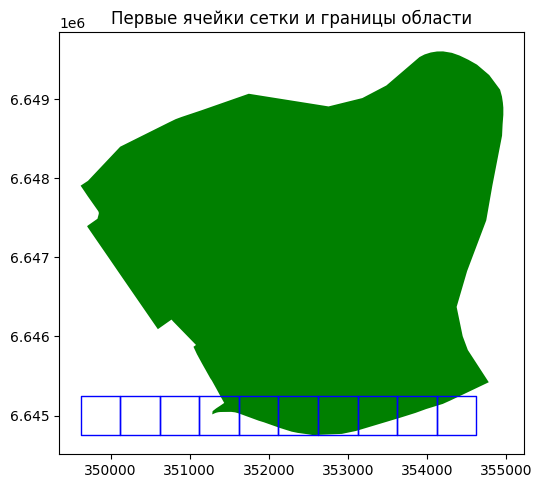

In [50]:
# Отобразим первые 10 ячеек
first_few = grid_cells[:10]

ax = gpd.GeoSeries(first_few, crs=utm_data).plot(
    figsize=(6,6), edgecolor='blue', facecolor='none', zorder=3
)

# Граница района
admin_border_utm.plot(ax=ax, color='green', linewidth=1)

plt.title("Первые ячейки сетки и границы области")
plt.show()


Обратите внимание, что сетка создаётся по ограничивающему прямоугольнику (bbox), поэтому часть ячеек может выходить за границы района. При необходимости такие ячейки можно дополнительно отфильтровать.


### 1.5. Преобразование сетки в GeoDataFrame

После генерации ячеек в виде списка геометрий необходимо преобразовать их в формат `GeoDataFrame`, чтобы с ними можно было выполнять дальнейшие пространственные операции.


In [51]:
# Собираем всё в GeoDataFrame
fishnet = gpd.GeoDataFrame({'geometry': grid_cells}, crs=utm_data)

fishnet.explore(tiles="cartodbpositron")

### 1.6. Функция для создания сетки

На основе реализованного алгоритма оформим функцию, которая будет создавать регулярную сетку. В качестве входных параметров она принимает геоданные (для определения границ области) и размер ячейки.

Внутри функции также реализована проверка системы координат: если данные находятся в географической системе координат, они автоматически перепроецируются в подходящую UTM-зону.


In [52]:
from shapely.geometry import box
import geopandas as gpd

def create_regular_grid(data, cell_size):

    # Проверка CRS
    if data.crs is None:
        raise ValueError("У входных данных не задана система координат (CRS).")

    if data.crs.is_geographic:
        data = data.to_crs(data.estimate_utm_crs())

    # Границы области
    minx, miny, maxx, maxy = data.total_bounds

    grid_cells = []
    cell_ids = []

    x = minx
    cell_id = 0  # счётчик ячеек

    while x < maxx:
        y = miny
        while y < maxy:
            grid_cells.append(
                box(x, y, x + cell_size, y + cell_size)
            )
            cell_ids.append(cell_id)
            cell_id += 1
            y += cell_size
        x += cell_size

    # GeoDataFrame
    grid = gpd.GeoDataFrame(
        {
            "cell_id": cell_ids,
            "geometry": grid_cells
        },
        crs=data.crs
    )

    return grid

Применим функцию к нашим данным и посмотрим на получившуюся сетку


In [53]:
grid = create_regular_grid(admin_border, 500)

grid.explore(tiles="cartodbpositron")

Сетка построена корректно, и теперь мы можем использовать её для дальнейшего анализа


## 2. Подсчёт количества точек в полигонах

После создания регулярной сетки можно перейти к анализу распределения точечных объектов. Для этого определим, сколько точек попадает в каждую ячейку сетки, выполнив пространственное объединение, а затем агрегируем полученные данные.


### 2.1. Пространственное объединение

Для того чтобы определить, в какую ячейку сетки попадает каждая точка, выполним пространственное объединение слоя точек (кафе) со слоем полигонов (ячейки сетки).

В качестве пространственного предиката используем `within`, так как нам необходимо определить, **внутри какого полигона расположена каждая точка**. В результате к каждой точке будут добавлены атрибуты соответствующей ячейки сетки.

При выполнении пространственного объединения важно, чтобы у наборов данных совпадала система координат. В нашем случае данные уже были перепроецированы в UTM-зону, поэтому дополнительная проверка не требуется.


In [54]:
# Пространственное объединение: определяем, в какую ячейку попадает каждое кафе
cafes_in_grid = gpd.sjoin(
    cafes_utm,
    grid,
    how="left",
    predicate="within"
)

Посмотрим на результат


In [55]:
cafes_in_grid[["name", "cell_id"]].head()

name  cell_id
element id                            
node    444776758      Wahaha     63.0
        446064734         NaN     41.0
        446064736  Flat White     41.0
        455299275     Хлебник     55.0
        652383850     Feromon     15.0

Теперь мы знаем, в какой ячейке сетки находится каждая точка кафе, и можем подсчитать количество точек в каждой ячейке.


### 2.2. Агрегирование данных

Подсчитаем количество точек, попавших в каждый полигон (ячейку сетки).


Сгруппируем данные по идентификатору ячейки (`cell_id`) и подсчитаем количество кафе в каждой из них:


In [56]:
cafes_count = (
    cafes_in_grid
    .groupby("cell_id")
    .size()
    .reset_index(name="cafe_count")
)

cafes_count.head()

,cell_id,cafe_count
0,4.0,8
1,5.0,24
2,6.0,3
3,12.0,2
4,13.0,30


После выполнения агрегирования у нас есть таблица с количеством кафе в каждой ячейке, однако она не содержит геометрии. Чтобы перейти к дальнейшему пространственному анализу и визуализации, необходимо присоединить полученные значения обратно к сетке.


### 2.3. Присоединение результатов к сетке


Присоединим результаты агрегирования к сетке с помощью табличного объединения по полю `cell_id`, чтобы каждая ячейка содержала информацию о количестве кафе.


In [57]:
# Объединяем сетку с результатами подсчёта
grid_with_counts = grid.merge(
    cafes_count,
    on="cell_id",
    how="left"
)

# Заполним пропуски (ячейки без кафе)
grid_with_counts["cafe_count"] = grid_with_counts["cafe_count"].fillna(0)

grid_with_counts.head()

,cell_id,geometry,cafe_count
0,0,"POLYGON ((350122.326 6644753.924, 350122.326 6...",0.0
1,1,"POLYGON ((350122.326 6645253.924, 350122.326 6...",0.0
2,2,"POLYGON ((350122.326 6645753.924, 350122.326 6...",0.0
3,3,"POLYGON ((350122.326 6646253.924, 350122.326 6...",0.0
4,4,"POLYGON ((350122.326 6646753.924, 350122.326 6...",8.0


### 2.4. Считаем плотность

После подсчёта количества кафе в каждой ячейке можно перейти к расчёту плотности. Для этого количество объектов в ячейке соотносят с её площадью.

Поскольку сетка построена в проекционной системе координат, площадь ячеек можно корректно вычислить в квадратных метрах. Затем, для удобства интерпретации, плотность выразим в количестве кафе на квадратный километр.

Сначала вычислим площадь каждой ячейки, затем переведём её в квадратные километры и рассчитаем плотность:


In [58]:
# Площадь ячеек в квадратных метрах
grid_with_counts["cell_area_m2"] = grid_with_counts.geometry.area

# Перевод площади в квадратные километры
grid_with_counts["cell_area_km2"] = grid_with_counts["cell_area_m2"] / 1_000_000

# Плотность кафе: количество на 1 км²
grid_with_counts["cafe_density"] = (
    grid_with_counts["cafe_count"] / grid_with_counts["cell_area_km2"]
)

Посмотрим на результат


In [60]:
grid_with_counts_nonzero = grid_with_counts[grid_with_counts["cafe_density"] > 0]

grid_with_counts_nonzero.explore(
    column="cafe_density",
    cmap="OrRd",
    legend=True,
    tiles="cartodbpositron"
)

На карте видно, что кафе в Центральном районе Санкт-Петербурга размещены неравномерно. Такая визуализация позволяет гораздо нагляднее оценить распределение объектов по сравнению с отображением отдельных точек.


На данном этапе мы получили карту, на которой значения показаны с помощью цветовой шкалы. Такой способ визуализации называется **картограммой** (или _choropleth_).

Важно помнить, что для таких карт **не стоит использовать абсолютные значения**. Дело в том, что картограмма показывает значения, привязанные к площади объектов.

В нашем случае все ячейки имеют одинаковую площадь, поэтому использование абсолютных значений не приведёт к искажению результата. Однако в общем случае это считается некорректным подходом, поэтому предпочтительнее использовать относительные показатели.

Поэтому для картограмм лучше использовать **относительные показатели**, такие как плотность (например, количество объектов на единицу площади). Это позволяет более корректно сравнивать разные участки территории.


## Итог

В этом разделе мы рассмотрели, как агрегировать точечные пространственные данные с помощью регулярной сетки.

Мы научились создавать сетку заданного размера, сопоставлять с ней точечные объекты с помощью пространственного объединения и выполнять агрегирование данных, подсчитывая количество объектов в каждой ячейке.

Дополнительно мы рассчитали плотность объектов и визуализировали результат в виде картограммы.

Таким образом, использование регулярной сетки позволяет перейти от анализа отдельных точек к выявлению пространственных закономерностей.
